In [2]:
# %matplotlib notebook
from pic.Hdf5Viewer import Hdf5Viewer
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u

from plasmapy import particles

In [15]:
def load_and_fuse_n_evolution(folder_path, species_list=None):
    """
    Load all h5 files in format 'number.h5' from a folder and fuse n_evolution_average arrays.
    
    Parameters:
    -----------
    folder_path : str
        Path to the folder containing the h5 files
    species_list : list, optional
        List of species to extract. If None, will detect species from first file.
    
    Returns:
    --------
    dict
        Dictionary with species symbols as keys and concatenated n_evolution_average arrays as values
    """
    import glob
    import os
    import h5py
    import numpy as np
    import re
    
    folder_path = os.path.abspath(folder_path)
    
    # Find all h5 files matching pattern "number.h5"
    h5_files = glob.glob(os.path.join(folder_path, "*.h5"))
    h5_files = [f for f in h5_files if re.match(r'.*[\\/](\d+)\.h5$', f)]
    h5_files.sort(key=lambda x: int(re.search(r'(\d+)\.h5$', x).group(1)))
    
    if not h5_files:
        print(f"No h5 files found in format 'number.h5' in {folder_path}")
        return {}
    
    print(f"Found {len(h5_files)} h5 files")
    
    # Detect species from first file if not provided
    if species_list is None:
        with h5py.File(h5_files[0], 'r') as f:
            species_list = [sp for sp in f.keys() if sp not in ['time', 'phi']]
    
    print(f"Extracting n_evolution_average for species: {species_list}")
    
    # Dictionary to store concatenated arrays
    fused_data = {sp: [] for sp in species_list}
    
    # Load and concatenate data from each file
    for h5_file in h5_files:
        with h5py.File(h5_file, 'r') as f:
            for sp in species_list:
                try:
                    if sp in f:
                        sp_group = f[sp]
                        if isinstance(sp_group, h5py.Group) and 'n_evolution_average' in sp_group.keys():
                            data = np.array(sp_group['n_evolution_average'])
                            fused_data[sp].append(data)
                except (KeyError, TypeError):
                    continue
    
    # Concatenate arrays for each species
    result = {}
    for sp, data_list in fused_data.items():
        if data_list:
            result[sp] = np.concatenate(data_list)
            print(f"{sp}: {len(result[sp])} time steps")
        else:
            print(f"Warning: No n_evolution_average data found for {sp}")
    
    return result

In [17]:
jaj = load_and_fuse_n_evolution(r"C:\Users\super\Desktop\1D-PIC-EA-23\data\2026-03-08_17h34 150V")

Found 16 h5 files
Extracting n_evolution_average for species: ['Ar 1+', 'EDF', 'EDF_instant', 'e-']
Ar 1+: 204800 time steps
e-: 204800 time steps


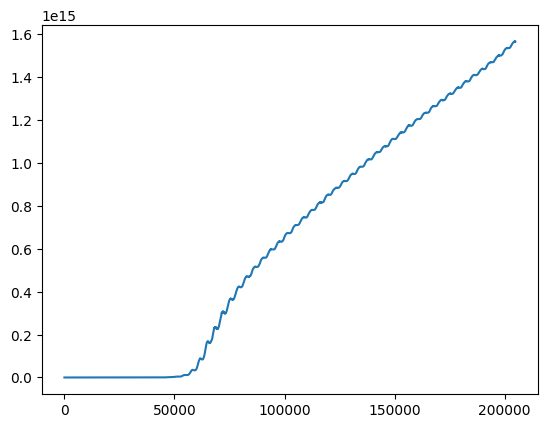

In [ ]:
plt.plot(jaj["e-"])
